In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
(x_train, y_train), (x_test,y_test)=tf.keras.datasets.mnist.load_data()
x_train=x_train.reshape(-1, 28*28) / 255.0
x_test=x_test.reshape(-1,28*28)/255.0

In [3]:
print(x_train.shape)
print(y_train.shape)


(60000, 784)
(60000,)


In [4]:
model=keras.Sequential([
keras.layers.Flatten(),
keras.layers.Dense(128),
keras.layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy')
model.fit(x_train, y_train, epochs=5)



Epoch 1/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2938
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2887
Epoch 3/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2847
Epoch 4/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2810
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2783


In [8]:
acc=model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 0s 774us/step - loss: 0.2758
Accuracy: 0.2757515609264374


In [6]:
pred=model.predict(x_test[:5])
print(pred)

1/1 [==============================] - 0s 68ms/step
[[5.1607771e-05 2.9243210e-09 6.3614272e-05 2.7036991e-03 1.0948530e-06
  1.8127004e-05 3.4843146e-09 9.9667549e-01 3.8238893e-05 4.4804884e-04]
 [3.6372803e-03 8.7387089e-06 9.6489757e-01 3.3531387e-03 9.0701613e-10
  6.5744342e-03 2.0228166e-02 1.3032773e-11 1.3006541e-03 5.9955045e-09]
 [8.6944392e-06 9.7868538e-01 8.7171607e-03 3.3947001e-03 1.3731816e-04
  9.3938777e-04 1.4563884e-03 1.3363144e-03 4.8152069e-03 5.0937891e-04]
 [9.9892694e-01 1.1942743e-10 1.3334295e-04 1.6887834e-05 5.0164875e-08
  5.5973855e-04 1.1446125e-04 8.4045510e-05 1.1869736e-04 4.5820776e-05]
 [1.6615404e-04 1.0923981e-06 2.0366851e-03 1.3458850e-04 9.3885010e-01
  3.6925692e-04 2.0312443e-03 9.2999674e-03 4.1348245e-03 4.2975914e-02]]


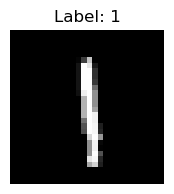

In [9]:
import matplotlib.pyplot as plt
sample_index= 8

image_to_plot = x_train[sample_index].reshape(28, 28)

plt.figure(figsize=(2, 2))
plt.imshow(image_to_plot, cmap="gray")
plt.title(f"Label: {y_train[sample_index]}")
plt.axis('off')
plt.show()


In [14]:
import pickle
import tensorflow as tf
import os

model.save('temp_mnist_model.h5')

with open('temp_mnist_model.h5', 'rb') as h5_file:
    model_bytes = h5_file.read()

with open('mnist_model.pkl', 'wb') as pkl_file:
    pickle.dump(model_bytes, pkl_file)

print("Model saved successfully as mnist_model.pkl")


with open('mnist_model.pkl', 'rb') as pkl_file:
    # Use load() to read from the file, not dump()
    reloaded_bytes = pickle.load(pkl_file) 


with open('reloaded_model.h5', 'wb') as h5_file:
    h5_file.write(reloaded_bytes)

reloaded_model = tf.keras.models.load_model('reloaded_model.h5')
print("Model reloaded successfully!")


Model saved successfully as mnist_model.pkl
Model reloaded successfully!


In [15]:

print("Your model is saved at:", os.getcwd())

Your model is saved at: C:\Users\batch1


In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [17]:
pkl_size = os.path.getsize('mnist_model.pkl')
print(f"Size of the .pkl file: {pkl_size} bytes")


Size of the .pkl file: 836089 bytes
